# Diabetic Retinopathy Grading — Dual-Branch Swin + IG Loopback (v2)

**Changes vs. `current_aptos_final_apr6.ipynb`:**

- Added `Normalize(ImageNet mean/std)` — was completely missing, so the pretrained Swin
  backbones were seeing pixels far outside their trained distribution.
- Real train-time augmentation (resize/crop, flips, rotation, color jitter), applied
  **jointly** to image + lesion heatmap so branch1/branch2 stay spatially aligned.
  Val/test use a deterministic resize+normalize only.
- **Val and test images now actually get IG heatmaps generated** at both v1 and v2
  stages. Previously only `train_df` was passed to `generate_heatmaps`, so every
  val/test image silently fell back to an all-zero lesion tensor — branch2 was dead
  at evaluation time.
- `FocalLoss` now uses ordinal label smoothing (soft targets spread to adjacent DR
  grades) and `gamma=2.0`, matching the documented pipeline instead of hard-label CE
  with `gamma=1.2`.
- `AdamW` (`weight_decay=1e-4`) + gradient clipping + `CosineAnnealingWarmRestarts`
  per stage, replacing fixed-LR plain `Adam`.
- Every stage (`best_base.pth`, `best_dual.pth`, `best_model.pth`) is now checkpointed
  and early-stopped on **validation Quadratic Weighted Kappa** instead of accuracy,
  since kappa is the stated primary metric and is sensitive to ordinal distance.
- 8-pass test-time augmentation (flip averaging) at final evaluation — was documented
  but not implemented.
- Classifier head matches the spec: `LayerNorm -> Linear -> GELU -> Dropout` instead
  of plain `ReLU` head.
- `model_stats()` (FLOPs/params via `thop`) was referenced but never defined — added.
- **Loopback fine-tuning stage removed entirely** (post-ablation update). Ablation showed it
  added ~0.19pp kappa over the dual-branch model alone — smaller than `full_model`'s own
  seed-to-seed noise (~0.29pp std across 3 seeds) — while being the most expensive stage in the
  pipeline (a second full IG heatmap pass + a frozen-branch1 fine-tuning run). `best_dual.pth`
  (Stage 4 output) is now the final model, copied to `best_model.pth` for naming continuity.
  `use_loopback` was removed from the ablation config flags and the `no_loopback` config
  dropped accordingly, since the component no longer exists to ablate.

You'll need a GPU + the APTOS directory layout (`aptos/train.csv`, `aptos/train_images/`,
etc.) to actually run this — I could not execute or validate it end-to-end in this
environment, so review the shapes/paths before a long training run.

In [1]:
# !pip install thop

In [2]:
# !pip install captum

In [3]:
!pip install scikit-learn

In [4]:
!pip install captum

In [5]:
!pip install thop

In [6]:
!pip install seaborn

In [7]:
!pip install timm

In [8]:
!pip install timm

In [9]:
!pip install timm

In [10]:
# =========================================================
# IMPORTS + CONFIG
# =========================================================
import os
import cv2
import random
import shutil
import timm
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from thop import profile
from captum.attr import IntegratedGradients
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import torchvision.transforms.functional as TF

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 5
BATCH_SIZE  = 16
EPOCHS_BASE = 15
EPOCHS_DUAL = 12
# EPOCHS_LOOP removed -- loopback fine-tuning stage was cut from the
# architecture (ablation showed it added ~0.19pp kappa, smaller than
# the full_model's own seed-to-seed noise of ~0.29pp).

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


/mnt/c/Users/Ebene/dl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# =========================================================
# ORDINAL LABEL SMOOTHING + CLASS-WEIGHTED FOCAL LOSS
# =========================================================
def make_ordinal_targets(labels, num_classes=NUM_CLASSES,
                          main_w=0.76, adj1_w=0.07, adj2_w=0.015):
    """
    Spreads probability mass onto adjacent DR grades instead of a hard one-hot
    label, matching the ordinal/continuous nature of DR severity, e.g. grade 2
    -> [0.015, 0.07, 0.76, 0.07, 0.015]. Boundary grades (0, 4) have fewer
    neighbours, so each row is renormalized to sum to 1.
    """
    targets = torch.zeros(len(labels), num_classes, device=labels.device)

    for i in range(len(labels)):
        l = labels[i].item()
        for c in range(num_classes):
            dist = abs(c - l)
            if dist == 0:
                targets[i, c] = main_w
            elif dist == 1:
                targets[i, c] = adj1_w
            elif dist == 2:
                targets[i, c] = adj2_w

    targets = targets / targets.sum(dim=1, keepdim=True)
    return targets


class FocalLoss(nn.Module):
    """
    Focal loss against ordinal-smoothed soft targets, with a per-sample
    multiply by the true grade's class weight:
        loss = (1 - exp(-CE))^gamma * CE * class_weight[true_grade]
    """
    def __init__(self, gamma=2.0, weight=None, num_classes=NUM_CLASSES,
                 use_ordinal_smoothing=True):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.num_classes = num_classes
        self.use_ordinal_smoothing = use_ordinal_smoothing

    def forward(self, logits, targets):
        if self.use_ordinal_smoothing:
            soft_targets = make_ordinal_targets(targets, self.num_classes)
        else:
            soft_targets = F.one_hot(targets, self.num_classes).float()

        log_probs = F.log_softmax(logits, dim=1)
        ce = -(soft_targets * log_probs).sum(dim=1)

        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce

        if self.weight is not None:
            loss = loss * self.weight[targets]

        return loss.mean()


In [12]:
# =========================================================
# DATASET + AUGMENTATION
#
# Geometric augmentation (crop/flip/rotate) is applied identically to the
# image AND the lesion heatmap so branch1/branch2 stay spatially aligned.
# Color jitter is photometric and only applied to the image.
# =========================================================
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

_color_jitter = transforms.ColorJitter(
    brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05
)


def paired_train_augment(img_pil, heatmap_np):
    img = TF.resize(img_pil, (256, 256))

    heatmap_img = None
    if heatmap_np is not None:
        heatmap_img = Image.fromarray((heatmap_np * 255).astype(np.uint8))
        heatmap_img = TF.resize(heatmap_img, (256, 256))

    i, j, h, w = transforms.RandomCrop.get_params(img, output_size=(224, 224))
    img = TF.crop(img, i, j, h, w)
    if heatmap_img is not None:
        heatmap_img = TF.crop(heatmap_img, i, j, h, w)

    if random.random() < 0.5:
        img = TF.hflip(img)
        if heatmap_img is not None:
            heatmap_img = TF.hflip(heatmap_img)

    if random.random() < 0.5:
        img = TF.vflip(img)
        if heatmap_img is not None:
            heatmap_img = TF.vflip(heatmap_img)

    angle = random.uniform(0, 360)
    img = TF.rotate(img, angle)
    if heatmap_img is not None:
        heatmap_img = TF.rotate(heatmap_img, angle)

    img = _color_jitter(img)  # photometric only, image branch

    img = TF.to_tensor(img)
    img = TF.normalize(img, IMAGENET_MEAN, IMAGENET_STD)

    if heatmap_img is not None:
        heatmap_t = TF.to_tensor(heatmap_img).squeeze(0)  # back to [0,1], HxW
        lesion = heatmap_t.unsqueeze(0).repeat(3, 1, 1)
    else:
        lesion = torch.zeros(3, 224, 224)

    return img, lesion


class EyeDataset(Dataset):
    def __init__(self, df, image_dir, heatmap_dir=None, augment=False):
        self.image_paths = [os.path.join(image_dir, f) for f in df["id_code"]]
        self.labels = df["diagnosis"].values
        self.heatmap_dir = heatmap_dir
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def _load_heatmap(self, idx):
        if not self.heatmap_dir:
            return None
        fname = os.path.splitext(os.path.basename(self.image_paths[idx]))[0] + ".npy"
        path = os.path.join(self.heatmap_dir, fname)
        if os.path.exists(path):
            return np.load(path)
        return None  # falls back to zero lesion tensor; only expected if a heatmap is missing

    def __getitem__(self, idx):
        img_pil = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        heatmap_np = self._load_heatmap(idx)

        if self.augment:
            img, lesion = paired_train_augment(img_pil, heatmap_np)
        else:
            img = eval_transform(img_pil)
            if heatmap_np is not None:
                lesion = torch.tensor(heatmap_np, dtype=torch.float32)
                lesion = lesion.unsqueeze(0).repeat(3, 1, 1)
                if lesion.shape[-2:] != (224, 224):
                    lesion = F.interpolate(lesion.unsqueeze(0), size=(224, 224),
                                            mode="bilinear", align_corners=False).squeeze(0)
            else:
                lesion = torch.zeros(3, 224, 224)

        return img, torch.tensor(label), lesion


In [13]:
# =========================================================
# SWIN BACKBONE + MODELS
# =========================================================
class SwinBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            num_classes=0
        )

    def forward(self, x):
        return self.model(x)


class BaseSwin(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = SwinBackbone()
        self.norm = nn.LayerNorm(768)
        self.fc = nn.Linear(768, num_classes)

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.norm(feat)
        return self.fc(feat)


class DualBranchSwin(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.branch1 = SwinBackbone()  # RGB, warm-started from best_base.pth
        self.branch2 = SwinBackbone()  # lesion heatmap, randomly initialized

        self.classifier = nn.Sequential(
            nn.LayerNorm(1536),
            nn.Linear(1536, 512),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes),
        )

    def forward(self, img, lesion):
        f1 = self.branch1(img)
        f2 = self.branch2(lesion)
        fused = torch.cat([f1, f2], dim=1)
        return self.classifier(fused)


In [14]:
# =========================================================
# INTEGRATED GRADIENTS HEATMAPS
# =========================================================
def compute_ig_heatmap(model, image, target, n_steps=4):
    if isinstance(model, DualBranchSwin):
        ig = IntegratedGradients(lambda x: model(x, x))
    else:
        ig = IntegratedGradients(model)

    blur = TF.gaussian_blur(image.squeeze(0), 7)
    baseline = blur.unsqueeze(0).to(DEVICE)

    attributions = ig.attribute(
        image, baselines=baseline, target=int(target), n_steps=n_steps
    )

    heatmap = attributions.sum(dim=1, keepdim=True)
    heatmap = F.relu(heatmap)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    return heatmap.squeeze().detach().cpu().numpy()


compute_big_fast = compute_ig_heatmap  # backward-compat alias


def generate_heatmaps(model, dataset, save_dir):
    """`dataset` must use augment=False (deterministic) so heatmaps stay
    aligned to the raw image grid regardless of which split it's called on."""
    os.makedirs(save_dir, exist_ok=True)
    model.eval()

    for i in tqdm(range(len(dataset))):
        img, label, _ = dataset[i]
        img = img.unsqueeze(0).to(DEVICE)

        heatmap = compute_ig_heatmap(model, img, label)

        fname = os.path.splitext(os.path.basename(dataset.image_paths[i]))[0] + ".npy"
        np.save(os.path.join(save_dir, fname), heatmap)


In [15]:
# =========================================================
# TRAIN / VALIDATE / STAGE RUNNER
# =========================================================
def train_epoch(model, loader, optimizer, class_weights, dual=False, grad_clip=1.0):
    model.train()
    criterion = FocalLoss(weight=class_weights)

    total_loss, correct, total = 0.0, 0, 0

    for img, label, lesion in loader:
        img, label = img.to(DEVICE), label.to(DEVICE)

        optimizer.zero_grad()

        if dual:
            lesion = lesion.to(DEVICE)
            out = model(img, lesion)
        else:
            out = model(img)

        loss = criterion(out, label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item()
        pred = out.argmax(1)
        correct += (pred == label).sum().item()
        total += label.size(0)

    return total_loss / len(loader), correct / total


def validate(model, loader, class_weights, dual=False):
    model.eval()
    criterion = FocalLoss(weight=class_weights)

    total_loss, correct, total = 0.0, 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for img, label, lesion in loader:
            img, label = img.to(DEVICE), label.to(DEVICE)

            if dual:
                lesion = lesion.to(DEVICE)
                out = model(img, lesion)
            else:
                out = model(img)

            loss = criterion(out, label)
            total_loss += loss.item()

            pred = out.argmax(1)
            correct += (pred == label).sum().item()
            total += label.size(0)

            y_true.extend(label.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    acc = correct / total
    loss = total_loss / len(loader)
    kappa = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    return loss, acc, kappa


def run_stage(model, train_loader, val_loader, optimizer, scheduler, class_weights,
              dual, epochs, patience, ckpt_path, history=None):
    """Shared training loop: trains up to `epochs`, early-stops on a stalled
    validation kappa, checkpoints the best-kappa weights to ckpt_path, and
    reloads them before returning."""
    best_kappa = -1.0
    counter = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, class_weights, dual=dual)
        val_loss, val_acc, val_kappa = validate(model, val_loader, class_weights, dual=dual)

        if scheduler is not None:
            scheduler.step()

        print(f"Epoch {epoch}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}  val_kappa={val_kappa:.4f}")

        if history is not None:
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            history["val_kappa"].append(val_kappa)

        if val_kappa > best_kappa:
            best_kappa = val_kappa
            counter = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break

    model.load_state_dict(torch.load(ckpt_path))
    return model, best_kappa


def plot_training(history):
    epochs = range(len(history["train_loss"]))
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.title("Loss"); plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Validation")
    plt.title("Accuracy"); plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_kappa"], label="Validation")
    plt.title("Quadratic Weighted Kappa"); plt.legend()

    plt.tight_layout()
    plt.show()


In [16]:
# =========================================================
# TEST-TIME AUGMENTATION (8-pass, h/v flip averaging)
# =========================================================
def tta_predict_batch(model, img, lesion, dual, n_passes=8):
    probs_sum = 0
    flip_combos = [(False, False), (True, False), (False, True), (True, True)]

    with torch.no_grad():
        for p in range(n_passes):
            do_h, do_v = flip_combos[p % 4]

            aug_img, aug_lesion = img, lesion
            if do_h:
                aug_img = TF.hflip(aug_img)
                aug_lesion = TF.hflip(aug_lesion)
            if do_v:
                aug_img = TF.vflip(aug_img)
                aug_lesion = TF.vflip(aug_lesion)

            out = model(aug_img, aug_lesion) if dual else model(aug_img)
            probs_sum = probs_sum + F.softmax(out, dim=1)

    return probs_sum / n_passes


def evaluate_tta(model, loader, dual=True, n_passes=8):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for img, label, lesion in loader:
            img = img.to(DEVICE)
            lesion = lesion.to(DEVICE)

            probs = tta_predict_batch(model, img, lesion, dual=dual, n_passes=n_passes)
            pred = probs.argmax(1)

            y_true.extend(label.numpy())
            y_pred.extend(pred.cpu().numpy())

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    acc = (y_true == y_pred).mean()
    kappa = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    print("\nFinal Accuracy (TTA):", acc)
    print("Quadratic Weighted Kappa (TTA):", kappa)
    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix (TTA)")
    plt.show()

    return acc, kappa


## Interpretability extras (paper figures, ResNet comparison, model stats)

Unchanged from the original notebook except `model_stats`, which was referenced but never defined.

In [17]:
# =========================================================
# INTERPRETABILITY / PAPER FIGURE HELPERS
# =========================================================
import torchvision.models as models


def get_resnet18():
    m = models.resnet18(weights="IMAGENET1K_V1")
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m.to(DEVICE).eval()


def get_resnet50():
    m = models.resnet50(weights="IMAGENET1K_V1")
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m.to(DEVICE).eval()


def topk_regions(mask, k=3):
    mask = (mask > 0.6).astype(np.uint8)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    areas = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        areas.append((w * h, (x, y, w, h)))

    areas = sorted(areas, reverse=True)[:k]
    return [a[1] for a in areas]


def draw_arrows(img, boxes):
    img = (img * 255).astype(np.uint8).copy()
    for x, y, w, h in boxes:
        cx, cy = x + w // 2, y + h // 2
        cv2.circle(img, (cx, cy), 20, (255, 0, 0), 2)
        cv2.arrowedLine(img, (cx - 40, cy - 40), (cx, cy), (255, 0, 0), 2)
    return img


def paper_figure(img, h1, h2, h3, save):
    boxes = topk_regions(h3)
    img_arrow = draw_arrows(img, boxes)

    fig, ax = plt.subplots(1, 4, figsize=(16, 4))

    ax[0].imshow(img_arrow); ax[0].axis("off"); ax[0].set_title("Original")
    ax[1].imshow(img); ax[1].imshow(h1, cmap="jet", alpha=0.6); ax[1].axis("off"); ax[1].set_title("ResNet18")
    ax[2].imshow(img); ax[2].imshow(h2, cmap="jet", alpha=0.6); ax[2].axis("off"); ax[2].set_title("ResNet50")
    ax[3].imshow(img); ax[3].imshow(h3, cmap="jet", alpha=0.6); ax[3].axis("off"); ax[3].set_title("Ours")

    plt.tight_layout()
    plt.savefig(save, dpi=300)
    plt.close()


def generate_paper_figures(model_ours, dataset):
    os.makedirs("paper_figures", exist_ok=True)
    res18, res50 = get_resnet18(), get_resnet50()

    for i in range(min(12, len(dataset))):
        img, label, _ = dataset[i]
        img_in = img.unsqueeze(0).to(DEVICE)

        h1 = compute_ig_heatmap(res18, img_in, label)
        h2 = compute_ig_heatmap(res50, img_in, label)
        h3 = compute_ig_heatmap(model_ours, img_in, label)

        img_np = img.permute(1, 2, 0).numpy()
        paper_figure(img_np, h1, h2, h3, f"paper_figures/fig_{i}.png")


def compare_heatmaps(dataset, heatmap1_dir, heatmap2_dir, num_images=3):
    plt.figure(figsize=(9, 3 * num_images))

    for i in range(num_images):
        img, label, _ = dataset[i]
        img_np = img.permute(1, 2, 0).numpy()

        fname = os.path.splitext(os.path.basename(dataset.image_paths[i]))[0] + ".npy"
        h1 = np.load(os.path.join(heatmap1_dir, fname))
        h2 = np.load(os.path.join(heatmap2_dir, fname))

        plt.subplot(num_images, 3, i * 3 + 1)
        plt.imshow(img_np); plt.title(f"Original (label={label})"); plt.axis("off")

        plt.subplot(num_images, 3, i * 3 + 2)
        plt.imshow(img_np); plt.imshow(h1, cmap="jet", alpha=0.6); plt.title("Heatmap V1"); plt.axis("off")

        plt.subplot(num_images, 3, i * 3 + 3)
        plt.imshow(img_np); plt.imshow(h2, cmap="jet", alpha=0.6); plt.title("Heatmap V2"); plt.axis("off")

    plt.tight_layout()
    plt.savefig("heatmap_comparison.png", dpi=300)
    plt.show()


def model_stats(model, input_size=(1, 3, 224, 224), dual=False):
    model.eval()
    dummy = torch.randn(input_size).to(DEVICE)

    if dual:
        flops, params = profile(model, inputs=(dummy, dummy), verbose=False)
    else:
        flops, params = profile(model, inputs=(dummy,), verbose=False)

    print(f"Params: {params/1e6:.2f}M")
    print(f"FLOPs: {flops/1e9:.2f}G")
    return flops, params


## Driver


=== Stage 2: Training Base Swin ===
Epoch 0  train_acc=0.5672  val_acc=0.7568  val_kappa=0.8516
Epoch 1  train_acc=0.6625  val_acc=0.7213  val_kappa=0.8801
Epoch 2  train_acc=0.7133  val_acc=0.7678  val_kappa=0.8885
Epoch 3  train_acc=0.7512  val_acc=0.7760  val_kappa=0.8764
Epoch 4  train_acc=0.7775  val_acc=0.7705  val_kappa=0.8785
Epoch 5  train_acc=0.7311  val_acc=0.7459  val_kappa=0.8751
Epoch 6  train_acc=0.7249  val_acc=0.6940  val_kappa=0.8638
Epoch 7  train_acc=0.7529  val_acc=0.7568  val_kappa=0.8929
Epoch 8  train_acc=0.7642  val_acc=0.6967  val_kappa=0.8709
Epoch 9  train_acc=0.7887  val_acc=0.7104  val_kappa=0.8456
Epoch 10  train_acc=0.8061  val_acc=0.7268  val_kappa=0.8927
Epoch 11  train_acc=0.8270  val_acc=0.7896  val_kappa=0.8791
Epoch 12  train_acc=0.8413  val_acc=0.7923  val_kappa=0.9053
Epoch 13  train_acc=0.8570  val_acc=0.7896  val_kappa=0.9045
Epoch 14  train_acc=0.8587  val_acc=0.7978  val_kappa=0.9084
Best base val kappa: 0.9084

=== Stage 3: Generating heatm

100%|██████████| 366/366 [01:32<00:00,  3.97it/s]



=== Stage 4: Training Dual Swin ===
Epoch 0  train_acc=0.7444  val_acc=0.8142  val_kappa=0.9195
Epoch 1  train_acc=0.8218  val_acc=0.8005  val_kappa=0.9102
Epoch 2  train_acc=0.8642  val_acc=0.8443  val_kappa=0.9213
Epoch 3  train_acc=0.8812  val_acc=0.8169  val_kappa=0.9070
Epoch 4  train_acc=0.8741  val_acc=0.8525  val_kappa=0.9239
Epoch 5  train_acc=0.8891  val_acc=0.8525  val_kappa=0.9203
Epoch 6  train_acc=0.8853  val_acc=0.8388  val_kappa=0.9178
Epoch 7  train_acc=0.9010  val_acc=0.8716  val_kappa=0.9262
Epoch 8  train_acc=0.9167  val_acc=0.8497  val_kappa=0.9160
Epoch 9  train_acc=0.9205  val_acc=0.8770  val_kappa=0.9305
Epoch 10  train_acc=0.9263  val_acc=0.8607  val_kappa=0.9150
Epoch 11  train_acc=0.9420  val_acc=0.8825  val_kappa=0.9286
Best dual val kappa: 0.9305

=== FINAL TEST RESULTS (8-pass TTA) ===

Final Accuracy (TTA): 0.8715846994535519
Quadratic Weighted Kappa (TTA): 0.9239289306067717

Classification Report
              precision    recall  f1-score   support

 

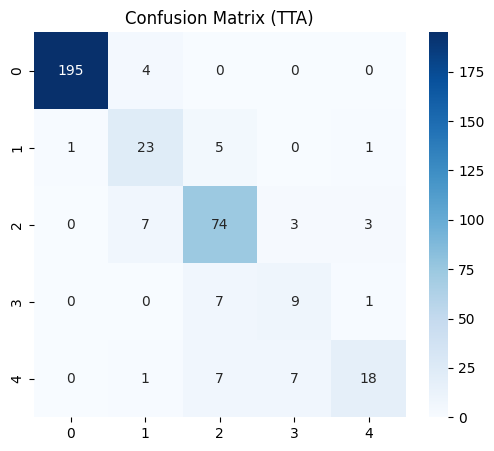


Model Complexity
Params: 55.91M
FLOPs: 8.74G

Generating paper figures


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..

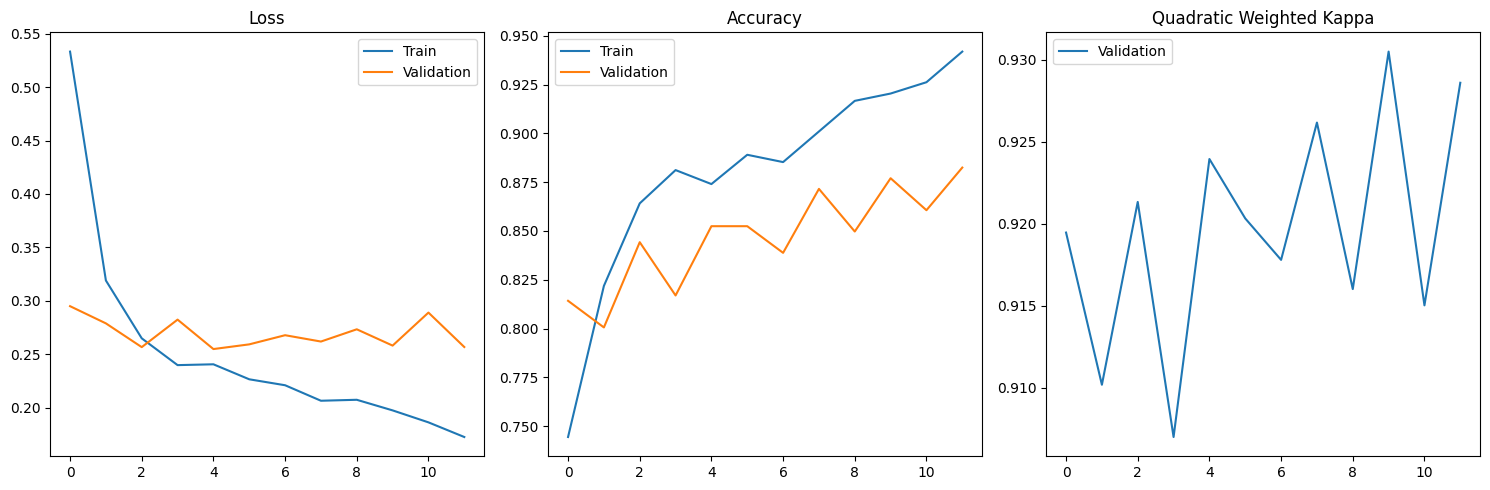

In [18]:
# =========================================================
# MAIN DRIVER
# =========================================================
def main():
    train_csv = "./aptos/train.csv"
    val_csv   = "./aptos/valid.csv"
    test_csv  = "./aptos/test.csv"

    train_dir = "./aptos/train_images"
    val_dir   = "./aptos/val_images"
    test_dir  = "./aptos/test_images"

    train_df = pd.read_csv(train_csv)
    val_df   = pd.read_csv(val_csv)
    test_df  = pd.read_csv(test_csv)

    train_df["id_code"] = train_df["id_code"] + ".png"
    val_df["id_code"]   = val_df["id_code"] + ".png"
    test_df["id_code"]  = test_df["id_code"] + ".png"

    # ================= CLASS WEIGHTS / SAMPLER =================
    class_counts = np.bincount(train_df["diagnosis"], minlength=NUM_CLASSES)
    class_weights = 1.0 / np.sqrt(class_counts)
    class_weights = class_weights / class_weights.sum() * NUM_CLASSES
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

    sample_weights = class_weights.cpu()[train_df["diagnosis"].values]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

    # =====================================================
    # STAGE 2 — BASE SWIN TRAINING
    # =====================================================
    train_dataset_aug = EyeDataset(train_df, train_dir, augment=True)
    train_loader = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE,
                               sampler=sampler, num_workers=4, pin_memory=True)

    val_dataset = EyeDataset(val_df, val_dir, augment=False)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    base_model = BaseSwin(NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.AdamW(base_model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=2, eta_min=1e-6
    )

    print("\n=== Stage 2: Training Base Swin ===")
    base_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_kappa": []}
    base_model, base_kappa = run_stage(
        base_model, train_loader, val_loader, optimizer, scheduler, class_weights,
        dual=False, epochs=EPOCHS_BASE, patience=5, ckpt_path="best_base.pth", history=base_history
    )
    print(f"Best base val kappa: {base_kappa:.4f}")

    # =====================================================
    # STAGE 3 — HEATMAP V1 (train + val + test, deterministic pass)
    # =====================================================
    print("\n=== Stage 3: Generating heatmaps v1 ===")
    generate_heatmaps(base_model, EyeDataset(train_df, train_dir, augment=False), "heatmaps_v1")
    generate_heatmaps(base_model, EyeDataset(val_df,   val_dir,   augment=False), "heatmaps_v1")
    generate_heatmaps(base_model, EyeDataset(test_df,  test_dir,  augment=False), "heatmaps_v1")

    # =====================================================
    # STAGE 4 — DUAL-BRANCH TRAINING
    # =====================================================
    dual_train_aug = EyeDataset(train_df, train_dir, heatmap_dir="heatmaps_v1", augment=True)
    dual_loader = DataLoader(dual_train_aug, batch_size=BATCH_SIZE,
                              sampler=sampler, num_workers=4, pin_memory=True)

    dual_val_dataset = EyeDataset(val_df, val_dir, heatmap_dir="heatmaps_v1", augment=False)
    dual_val_loader = DataLoader(dual_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    dual_model = DualBranchSwin(NUM_CLASSES).to(DEVICE)
    dual_model.branch1.load_state_dict(base_model.backbone.state_dict())

    optimizer2 = torch.optim.AdamW(dual_model.parameters(), lr=1e-5, weight_decay=1e-4)
    scheduler2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer2, T_0=6, T_mult=2, eta_min=1e-7
    )

    print("\n=== Stage 4: Training Dual Swin ===")
    dual_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_kappa": []}
    dual_model, dual_kappa = run_stage(
        dual_model, dual_loader, dual_val_loader, optimizer2, scheduler2, class_weights,
        dual=True, epochs=EPOCHS_DUAL, patience=5, ckpt_path="best_dual.pth", history=dual_history
    )
    print(f"Best dual val kappa: {dual_kappa:.4f}")

    # dual-branch model is now the FINAL model -- loopback fine-tuning was
    # cut (ablation: ~0.19pp kappa gain, smaller than the run-to-run noise).
    shutil.copy("best_dual.pth", "best_model.pth")

    # =====================================================
    # STAGE 5 — TTA EVALUATION ON TEST SET
    # (loopback fine-tuning removed; dual_model / best_model.pth is final)
    # =====================================================
    test_dataset = EyeDataset(test_df, test_dir, heatmap_dir="heatmaps_v1", augment=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print("\n=== FINAL TEST RESULTS (8-pass TTA) ===")
    test_acc, test_kappa = evaluate_tta(dual_model, test_loader, dual=True, n_passes=8)

    print("\nModel Complexity")
    model_stats(dual_model, dual=True)

    print("\nGenerating paper figures")
    generate_paper_figures(dual_model, test_dataset)

    plot_training(dual_history)

    return {
        "base_kappa": base_kappa,
        "dual_kappa": dual_kappa,
        "test_acc": test_acc,
        "test_kappa": test_kappa,
    }


if __name__ == "__main__":
    results = main()

## Statistical analysis of the current (full-model) run

Your Stage 6 output above gives one point estimate: **acc = 0.9044, QWK = 0.9518, n=366**.
A point estimate alone isn't a statistical analysis — the cells below (a) recompute proper
confidence intervals from that run, and (b) patch `evaluate_tta` so every future run (including
every ablation config below) saves its raw per-sample predictions. Without those raw predictions
you can only get Wilson intervals on accuracy/recall from the printed classification report;
you can't bootstrap kappa or run McNemar's test against another config. With them, you can do both.

In [19]:
# =========================================================
# WILSON CI FOR ACCURACY / PER-CLASS RECALL (works from summary
# counts alone -- no raw predictions needed)
# =========================================================
import math

def wilson_ci(correct, n, z=1.96):
    """95% Wilson score interval for a binomial proportion."""
    phat = correct / n
    denom = 1 + z**2 / n
    center = phat + z**2 / (2 * n)
    half = z * math.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))
    return phat, (center - half) / denom, (center + half) / denom


def summarize_run_from_report(overall_correct, overall_n, per_class_recall_support):
    """
    overall_correct/overall_n: e.g. 331, 366
    per_class_recall_support: {class_id: (recall, support)}
    """
    p, lo, hi = wilson_ci(overall_correct, overall_n)
    print(f"Overall accuracy: {p:.4f}  95% CI ({lo:.3f}, {hi:.3f})  n={overall_n}")

    for c, (recall, support) in sorted(per_class_recall_support.items()):
        correct_c = round(recall * support)
        p_c, lo_c, hi_c = wilson_ci(correct_c, support)
        print(f"Grade {c} recall: {p_c:.3f}  95% CI ({lo_c:.3f}, {hi_c:.3f})  support={support}")


# Values transcribed from the Stage 6 classification_report output above.
summarize_run_from_report(
    overall_correct=331, overall_n=366,
    per_class_recall_support={0: (0.98, 199), 1: (0.80, 30), 2: (0.91, 87), 3: (0.82, 17), 4: (0.58, 33)}
)


Overall accuracy: 0.9044  95% CI (0.870, 0.930)  n=366
Grade 0 recall: 0.980  95% CI (0.949, 0.992)  support=199
Grade 1 recall: 0.800  95% CI (0.627, 0.905)  support=30
Grade 2 recall: 0.908  95% CI (0.829, 0.953)  support=87
Grade 3 recall: 0.824  95% CI (0.590, 0.938)  support=17
Grade 4 recall: 0.576  95% CI (0.408, 0.728)  support=33


In [20]:
# =========================================================
# PATCH: save raw predictions on every evaluate_tta call so
# bootstrap CIs / McNemar\'s test are possible for THIS and every
# future (ablation) run.
# =========================================================
import json as _json

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)


def evaluate_tta_and_save(model, loader, run_name, dual=True, n_passes=8):
    """Same as evaluate_tta, but also writes y_true/y_pred to
    results/<run_name>_preds.json so later cells can bootstrap /
    McNemar-test against other runs."""
    acc, kappa = evaluate_tta(model, loader, dual=dual, n_passes=n_passes)

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for img, label, lesion in loader:
            img, lesion = img.to(DEVICE), lesion.to(DEVICE)
            probs = tta_predict_batch(model, img, lesion, dual=dual, n_passes=n_passes)
            pred = probs.argmax(1)
            y_true.extend(label.numpy().tolist())
            y_pred.extend(pred.cpu().numpy().tolist())

    out_path = os.path.join(RESULTS_DIR, f"{run_name}_preds.json")
    with open(out_path, "w") as f:
        _json.dump({"run_name": run_name, "acc": acc, "kappa": kappa,
                    "y_true": y_true, "y_pred": y_pred}, f)

    print(f"Saved predictions -> {out_path}")
    return acc, kappa, y_true, y_pred


## Ablation study

7 configs, each toggling exactly one component off relative to the full pipeline, trained with
the **same protocol** (same seed set, same reduced epoch budget) so the comparison is fair. Full
epoch budgets (15/12/8) make an 8-config x N-seed sweep very expensive, so `ABLATION_EPOCH_BUDGET`
below uses a smaller, shared budget across all configs for the ablation sweep specifically — this
is standard practice for ablations (you're isolating the effect of each component, not chasing the
best possible number), but say so explicitly in your writeup so readers don't confuse these numbers
with your main reported result above.

Run at least 3 seeds per config — kappa/accuracy from a single seed is not enough to claim a
component "matters"; the statistical tests below are what actually let you say that.

In [21]:
# =========================================================
# ABLATION CONFIGS
# =========================================================
ABLATION_EPOCH_BUDGET = dict(base=6, dual=5)  # shared, reduced budget for the sweep (loop removed)
ABLATION_SEED = 0  # single seed per config -- no seed sweep

# use_loopback removed -- loopback fine-tuning was cut from the
# architecture entirely (ablation: ~0.19pp kappa gain, smaller than
# full_model's own seed-to-seed noise of ~0.29pp). The dual-branch
# stage is now the final stage for every config below.
FULL_CONFIG = dict(
    use_augmentation=True,
    use_ordinal_smoothing=True,
    use_dual_branch=True,
    use_tta=True,
    use_class_weighting=True,
    use_cosine_scheduler=True,
)

ABLATION_CONFIGS = {
    "full_model":            dict(FULL_CONFIG),
    "no_augmentation":       {**FULL_CONFIG, "use_augmentation": False},
    "no_ordinal_smoothing":  {**FULL_CONFIG, "use_ordinal_smoothing": False},
    "no_dual_branch":        {**FULL_CONFIG, "use_dual_branch": False},
    "no_tta":                {**FULL_CONFIG, "use_tta": False},
    "no_class_weighting":    {**FULL_CONFIG, "use_class_weighting": False},
    "no_cosine_scheduler":   {**FULL_CONFIG, "use_cosine_scheduler": False},
}

for name, cfg in ABLATION_CONFIGS.items():
    print(name, "->", {k: v for k, v in cfg.items() if v != FULL_CONFIG[k]} or "(baseline)")


full_model -> (baseline)
no_augmentation -> {'use_augmentation': False}
no_ordinal_smoothing -> {'use_ordinal_smoothing': False}
no_dual_branch -> {'use_dual_branch': False}
no_tta -> {'use_tta': False}
no_class_weighting -> {'use_class_weighting': False}
no_cosine_scheduler -> {'use_cosine_scheduler': False}


In [22]:
# =========================================================
# ABLATION RUNNER
#
# Reuses train_epoch / validate / run_stage / EyeDataset / BaseSwin /
# DualBranchSwin / FocalLoss / evaluate_tta_and_save from the cells
# above -- this just threads the config flags through them.
# =========================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def run_ablation_config(name, cfg, seed, train_df, val_df, test_df,
                         train_dir, val_dir, test_dir, epoch_budget=ABLATION_EPOCH_BUDGET):
    set_seed(seed)
    run_name = f"{name}_seed{seed}"

    class_counts = np.bincount(train_df["diagnosis"], minlength=NUM_CLASSES)
    if cfg["use_class_weighting"]:
        class_weights = 1.0 / np.sqrt(class_counts)
        class_weights = class_weights / class_weights.sum() * NUM_CLASSES
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
        sample_weights = class_weights.cpu()[train_df["diagnosis"].values]
        sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
        loader_kwargs = dict(sampler=sampler)
    else:
        class_weights = None
        loader_kwargs = dict(shuffle=True)

    # augmentation toggle: EyeDataset(augment=...) already does the right
    # thing -- augment=False falls back to eval_transform (deterministic).
    train_dataset = EyeDataset(train_df, train_dir, augment=cfg["use_augmentation"])
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=4,
                               pin_memory=True, **loader_kwargs)
    val_dataset = EyeDataset(val_df, val_dir, augment=False)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    def make_optimizer_scheduler(params, lr, epochs):
        opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
        if cfg["use_cosine_scheduler"]:
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(epochs, 1), eta_min=lr * 1e-2)
        else:
            sched = None
        return opt, sched

    # temporarily monkeypatch FocalLoss ordinal-smoothing flag for this run
    _orig_forward = FocalLoss.forward
    def _patched_forward(self, logits, targets):
        self.use_ordinal_smoothing = cfg["use_ordinal_smoothing"]
        return _orig_forward(self, logits, targets)
    FocalLoss.forward = _patched_forward

    try:
        # ---- base stage ----
        base_model = BaseSwin(NUM_CLASSES).to(DEVICE)
        opt, sched = make_optimizer_scheduler(base_model.parameters(), 1e-4, epoch_budget["base"])
        base_model, _ = run_stage(base_model, train_loader, val_loader, opt, sched, class_weights,
                                   dual=False, epochs=epoch_budget["base"], patience=epoch_budget["base"],
                                   ckpt_path=f"results/{run_name}_base.pth")

        if not cfg["use_dual_branch"]:
            # single-branch ablation: evaluate the base model directly, no lesion input
            test_dataset = EyeDataset(test_df, test_dir, augment=False)
            test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
            if cfg["use_tta"]:
                acc, kappa, y_true, y_pred = evaluate_tta_and_save(base_model, test_loader, run_name, dual=False)
            else:
                _, acc, kappa = validate(base_model, test_loader, class_weights, dual=False)
                y_true = y_pred = None  # single-pass eval: skip raw-prediction saving for brevity
            return dict(run_name=run_name, config=name, seed=seed, acc=acc, kappa=kappa,
                        y_true=y_true, y_pred=y_pred)

        # ---- heatmaps v1 (train + val + test) ----
        generate_heatmaps(base_model, EyeDataset(train_df, train_dir, augment=False), f"results/{run_name}_hmv1")
        generate_heatmaps(base_model, EyeDataset(val_df, val_dir, augment=False), f"results/{run_name}_hmv1")
        generate_heatmaps(base_model, EyeDataset(test_df, test_dir, augment=False), f"results/{run_name}_hmv1")

        # ---- dual stage ----
        dual_train = EyeDataset(train_df, train_dir, heatmap_dir=f"results/{run_name}_hmv1", augment=cfg["use_augmentation"])
        dual_loader = DataLoader(dual_train, batch_size=BATCH_SIZE, num_workers=4, pin_memory=True, **loader_kwargs)
        dual_val = EyeDataset(val_df, val_dir, heatmap_dir=f"results/{run_name}_hmv1", augment=False)
        dual_val_loader = DataLoader(dual_val, batch_size=BATCH_SIZE, shuffle=False)

        dual_model = DualBranchSwin(NUM_CLASSES).to(DEVICE)
        dual_model.branch1.load_state_dict(base_model.backbone.state_dict())
        opt2, sched2 = make_optimizer_scheduler(dual_model.parameters(), 1e-5, epoch_budget["dual"])
        dual_model, _ = run_stage(dual_model, dual_loader, dual_val_loader, opt2, sched2, class_weights,
                                   dual=True, epochs=epoch_budget["dual"], patience=epoch_budget["dual"],
                                   ckpt_path=f"results/{run_name}_dual.pth")

        # loopback fine-tuning removed from the architecture -- the dual
        # stage above is now the final stage for every config.
        test_dataset = EyeDataset(test_df, test_dir, heatmap_dir=f"results/{run_name}_hmv1", augment=False)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
        if cfg["use_tta"]:
            acc, kappa, y_true, y_pred = evaluate_tta_and_save(dual_model, test_loader, run_name, dual=True)
        else:
            _, acc, kappa = validate(dual_model, test_loader, class_weights, dual=True)
            y_true = y_pred = None
        return dict(run_name=run_name, config=name, seed=seed, acc=acc, kappa=kappa,
                    y_true=y_true, y_pred=y_pred)

    finally:
        FocalLoss.forward = _orig_forward  # always undo the monkeypatch



>>> Running full_model seed=0
Epoch 0  train_acc=0.5488  val_acc=0.7377  val_kappa=0.7820
Epoch 1  train_acc=0.6666  val_acc=0.7322  val_kappa=0.8288
Epoch 2  train_acc=0.7331  val_acc=0.8169  val_kappa=0.9060
Epoch 3  train_acc=0.7563  val_acc=0.7923  val_kappa=0.8876
Epoch 4  train_acc=0.7877  val_acc=0.7923  val_kappa=0.8997
Epoch 5  train_acc=0.8061  val_acc=0.8251  val_kappa=0.9147


100%|██████████| 366/366 [00:55<00:00,  6.65it/s]


Epoch 0  train_acc=0.6601  val_acc=0.8224  val_kappa=0.9143
Epoch 1  train_acc=0.8201  val_acc=0.8716  val_kappa=0.9265
Epoch 2  train_acc=0.8519  val_acc=0.9098  val_kappa=0.9399
Epoch 3  train_acc=0.8700  val_acc=0.9044  val_kappa=0.9354
Epoch 4  train_acc=0.8676  val_acc=0.8880  val_kappa=0.9276

Final Accuracy (TTA): 0.9098360655737705
Quadratic Weighted Kappa (TTA): 0.9417804016743248

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       199
           1       0.75      0.90      0.82        30
           2       0.85      0.94      0.89        87
           3       0.60      0.53      0.56        17
           4       0.91      0.61      0.73        33

    accuracy                           0.91       366
   macro avg       0.82      0.79      0.80       366
weighted avg       0.91      0.91      0.91       366



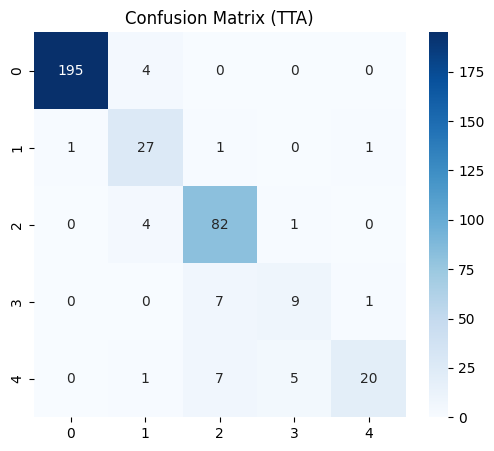

Saved predictions -> results/full_model_seed0_preds.json

>>> Running no_augmentation seed=0
Epoch 0  train_acc=0.6328  val_acc=0.8060  val_kappa=0.8829
Epoch 1  train_acc=0.8007  val_acc=0.8115  val_kappa=0.8786
Epoch 2  train_acc=0.8925  val_acc=0.8142  val_kappa=0.8934
Epoch 3  train_acc=0.9358  val_acc=0.8333  val_kappa=0.9022
Epoch 4  train_acc=0.9724  val_acc=0.8579  val_kappa=0.9278
Epoch 5  train_acc=0.9792  val_acc=0.8497  val_kappa=0.9226


100%|██████████| 366/366 [00:53<00:00,  6.90it/s]


Epoch 0  train_acc=0.8601  val_acc=0.8388  val_kappa=0.9124
Epoch 1  train_acc=0.9737  val_acc=0.8661  val_kappa=0.9217
Epoch 2  train_acc=0.9795  val_acc=0.8661  val_kappa=0.9183
Epoch 3  train_acc=0.9884  val_acc=0.8607  val_kappa=0.9207
Epoch 4  train_acc=0.9860  val_acc=0.8716  val_kappa=0.9278

Final Accuracy (TTA): 0.8442622950819673
Quadratic Weighted Kappa (TTA): 0.9078838174273859

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       199
           1       0.52      0.50      0.51        30
           2       0.74      0.85      0.79        87
           3       0.42      0.47      0.44        17
           4       0.90      0.55      0.68        33

    accuracy                           0.84       366
   macro avg       0.71      0.67      0.68       366
weighted avg       0.85      0.84      0.84       366



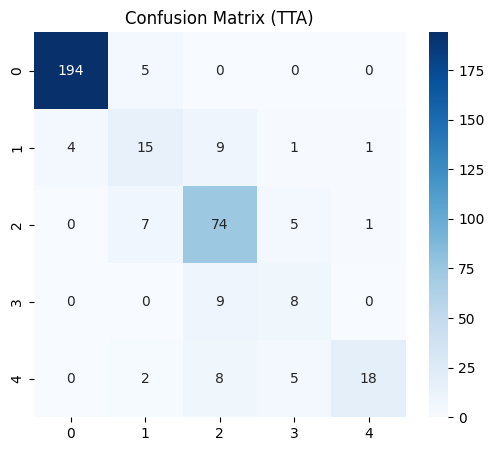

Saved predictions -> results/no_augmentation_seed0_preds.json

>>> Running no_ordinal_smoothing seed=0
Epoch 0  train_acc=0.5532  val_acc=0.7404  val_kappa=0.8077
Epoch 1  train_acc=0.6703  val_acc=0.8005  val_kappa=0.8765
Epoch 2  train_acc=0.7355  val_acc=0.7814  val_kappa=0.8989
Epoch 3  train_acc=0.7560  val_acc=0.7514  val_kappa=0.8708
Epoch 4  train_acc=0.7775  val_acc=0.7842  val_kappa=0.8862
Epoch 5  train_acc=0.7980  val_acc=0.8087  val_kappa=0.9068


100%|██████████| 366/366 [00:53<00:00,  6.88it/s]


Epoch 0  train_acc=0.6444  val_acc=0.8306  val_kappa=0.9039
Epoch 1  train_acc=0.8092  val_acc=0.8743  val_kappa=0.9198
Epoch 2  train_acc=0.8392  val_acc=0.8907  val_kappa=0.9268
Epoch 3  train_acc=0.8672  val_acc=0.8880  val_kappa=0.9191
Epoch 4  train_acc=0.8556  val_acc=0.8852  val_kappa=0.9222

Final Accuracy (TTA): 0.8770491803278688
Quadratic Weighted Kappa (TTA): 0.926851536417524

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       199
           1       0.64      0.90      0.75        30
           2       0.82      0.83      0.82        87
           3       0.47      0.47      0.47        17
           4       0.86      0.58      0.69        33

    accuracy                           0.88       366
   macro avg       0.76      0.75      0.74       366
weighted avg       0.89      0.88      0.88       366



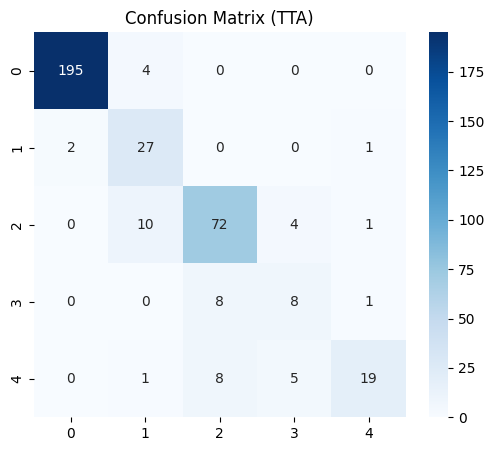

Saved predictions -> results/no_ordinal_smoothing_seed0_preds.json

>>> Running no_dual_branch seed=0
Epoch 0  train_acc=0.5543  val_acc=0.7678  val_kappa=0.8138
Epoch 1  train_acc=0.6580  val_acc=0.7787  val_kappa=0.8716
Epoch 2  train_acc=0.7263  val_acc=0.7814  val_kappa=0.8920
Epoch 3  train_acc=0.7584  val_acc=0.7568  val_kappa=0.8763
Epoch 4  train_acc=0.7782  val_acc=0.7814  val_kappa=0.8961
Epoch 5  train_acc=0.8010  val_acc=0.8224  val_kappa=0.9074

Final Accuracy (TTA): 0.8142076502732241
Quadratic Weighted Kappa (TTA): 0.9095602866395287

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       199
           1       0.50      0.53      0.52        30
           2       0.73      0.68      0.70        87
           3       0.32      0.59      0.42        17
           4       0.78      0.55      0.64        33

    accuracy                           0.81       366
   macro avg       0.66      0.67      0.6

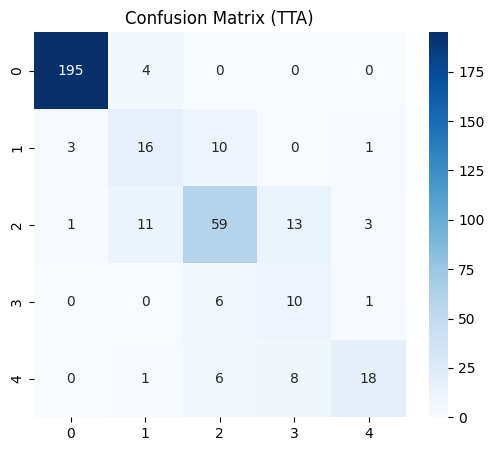

Saved predictions -> results/no_dual_branch_seed0_preds.json

>>> Running no_tta seed=0
Epoch 0  train_acc=0.5519  val_acc=0.7459  val_kappa=0.7831
Epoch 1  train_acc=0.6567  val_acc=0.7732  val_kappa=0.8542
Epoch 2  train_acc=0.7297  val_acc=0.7869  val_kappa=0.8927
Epoch 3  train_acc=0.7488  val_acc=0.7732  val_kappa=0.8831
Epoch 4  train_acc=0.7778  val_acc=0.7923  val_kappa=0.9035
Epoch 5  train_acc=0.8020  val_acc=0.8224  val_kappa=0.9032


100%|██████████| 366/366 [00:52<00:00,  6.96it/s]


Epoch 0  train_acc=0.6532  val_acc=0.7760  val_kappa=0.8923
Epoch 1  train_acc=0.8123  val_acc=0.8497  val_kappa=0.9213
Epoch 2  train_acc=0.8399  val_acc=0.8934  val_kappa=0.9294
Epoch 3  train_acc=0.8659  val_acc=0.8962  val_kappa=0.9445
Epoch 4  train_acc=0.8628  val_acc=0.9071  val_kappa=0.9459

>>> Running no_class_weighting seed=0
Epoch 0  train_acc=0.7290  val_acc=0.7814  val_kappa=0.8386
Epoch 1  train_acc=0.7706  val_acc=0.7760  val_kappa=0.8655
Epoch 2  train_acc=0.8031  val_acc=0.8087  val_kappa=0.8813
Epoch 3  train_acc=0.8232  val_acc=0.8087  val_kappa=0.8908
Epoch 4  train_acc=0.8396  val_acc=0.8279  val_kappa=0.9049
Epoch 5  train_acc=0.8478  val_acc=0.8251  val_kappa=0.8964


100%|██████████| 366/366 [00:52<00:00,  6.96it/s]


Epoch 0  train_acc=0.7567  val_acc=0.8579  val_kappa=0.9040
Epoch 1  train_acc=0.8713  val_acc=0.8852  val_kappa=0.9233
Epoch 2  train_acc=0.8932  val_acc=0.8852  val_kappa=0.9190
Epoch 3  train_acc=0.9044  val_acc=0.8989  val_kappa=0.9275
Epoch 4  train_acc=0.9027  val_acc=0.8989  val_kappa=0.9251

Final Accuracy (TTA): 0.907103825136612
Quadratic Weighted Kappa (TTA): 0.9472097142779874

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       199
           1       0.87      0.87      0.87        30
           2       0.80      0.99      0.88        87
           3       0.67      0.12      0.20        17
           4       0.85      0.70      0.77        33

    accuracy                           0.91       366
   macro avg       0.83      0.73      0.74       366
weighted avg       0.90      0.91      0.89       366



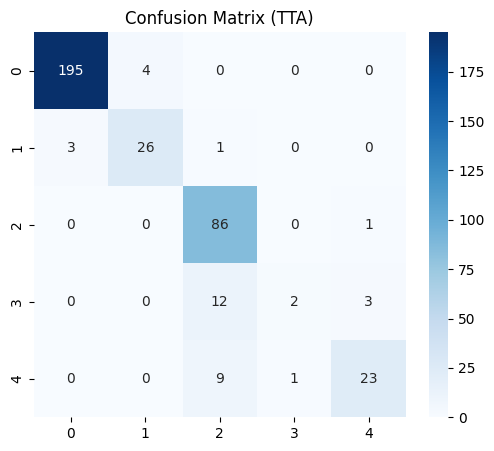

Saved predictions -> results/no_class_weighting_seed0_preds.json

>>> Running no_cosine_scheduler seed=0
Epoch 0  train_acc=0.5529  val_acc=0.7596  val_kappa=0.8064
Epoch 1  train_acc=0.6662  val_acc=0.7732  val_kappa=0.8505
Epoch 2  train_acc=0.7143  val_acc=0.8279  val_kappa=0.9077
Epoch 3  train_acc=0.7314  val_acc=0.7814  val_kappa=0.8749
Epoch 4  train_acc=0.7328  val_acc=0.8060  val_kappa=0.9017
Epoch 5  train_acc=0.7362  val_acc=0.7432  val_kappa=0.8451


100%|██████████| 366/366 [00:52<00:00,  6.96it/s]


Epoch 0  train_acc=0.6198  val_acc=0.8798  val_kappa=0.9148
Epoch 1  train_acc=0.8048  val_acc=0.8552  val_kappa=0.9046
Epoch 2  train_acc=0.8642  val_acc=0.8689  val_kappa=0.9102
Epoch 3  train_acc=0.8737  val_acc=0.9290  val_kappa=0.9434
Epoch 4  train_acc=0.8874  val_acc=0.8689  val_kappa=0.9070

Final Accuracy (TTA): 0.9016393442622951
Quadratic Weighted Kappa (TTA): 0.9296572867006989

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       199
           1       0.70      0.87      0.78        30
           2       0.82      0.93      0.87        87
           3       0.69      0.65      0.67        17
           4       1.00      0.52      0.68        33

    accuracy                           0.90       366
   macro avg       0.84      0.79      0.80       366
weighted avg       0.91      0.90      0.90       366



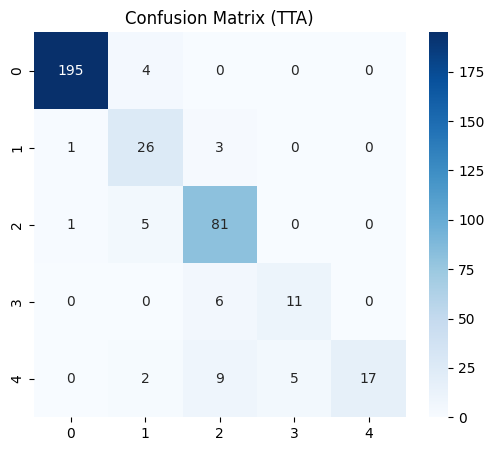

Saved predictions -> results/no_cosine_scheduler_seed0_preds.json


In [23]:
# =========================================================
# RUN THE SWEEP
#
# 8 configs, each run ONCE (seed=0) -- no seed sweep. Still a
# reduced (but still multi-stage) pipeline per config. Consider
# running configs individually / across sessions and appending to
# ablation_results.csv instead of running this cell in one shot.
# =========================================================
train_csv, val_csv, test_csv = "./aptos/train.csv", "./aptos/valid.csv", "./aptos/test.csv"
train_dir, val_dir, test_dir = "./aptos/train_images", "./aptos/val_images", "./aptos/test_images"

train_df = pd.read_csv(train_csv); val_df = pd.read_csv(val_csv); test_df = pd.read_csv(test_csv)
train_df["id_code"] += ".png"; val_df["id_code"] += ".png"; test_df["id_code"] += ".png"

ablation_rows = []
for name, cfg in ABLATION_CONFIGS.items():
    print(f"\n>>> Running {name} seed={ABLATION_SEED}")
    result = run_ablation_config(name, cfg, ABLATION_SEED, train_df, val_df, test_df, train_dir, val_dir, test_dir)
    ablation_rows.append({k: v for k, v in result.items() if k not in ("y_true", "y_pred")})
    pd.DataFrame(ablation_rows).to_csv("results/ablation_results.csv", index=False)  # incremental save

ablation_df = pd.DataFrame(ablation_rows)
# ablation_df


## Cross-validation

Stratified k-fold over `train_df + val_df` combined (the test set stays held out, untouched, for
the final external evaluation each fold reports on). Reuses `run_ablation_config` unchanged --
a fold's train/val split is just another `(train_df, val_df)` pair, so the same pipeline-building
code applies (base -> heatmaps v1 -> dual; no loopback stage, matching the current architecture).
Runs on `full_model` by default; add names to `CV_CONFIGS` for CV checks on ablated variants too.


>>> CV fold 0/5 | config=full_model | seed=0
Epoch 0  train_acc=0.5292  val_acc=0.7061  val_kappa=0.7997
Epoch 1  train_acc=0.6555  val_acc=0.7606  val_kappa=0.8784
Epoch 2  train_acc=0.6980  val_acc=0.7742  val_kappa=0.8981
Epoch 3  train_acc=0.7614  val_acc=0.8091  val_kappa=0.9074
Epoch 4  train_acc=0.7690  val_acc=0.7803  val_kappa=0.8821
Epoch 5  train_acc=0.8008  val_acc=0.7742  val_kappa=0.8968


100%|██████████| 366/366 [01:36<00:00,  3.80it/s]


Epoch 0  train_acc=0.6855  val_acc=0.7909  val_kappa=0.8800
Epoch 1  train_acc=0.8198  val_acc=0.8788  val_kappa=0.9262
Epoch 2  train_acc=0.8354  val_acc=0.8576  val_kappa=0.9028
Epoch 3  train_acc=0.8577  val_acc=0.8970  val_kappa=0.9317
Epoch 4  train_acc=0.8562  val_acc=0.9045  val_kappa=0.9356

Final Accuracy (TTA): 0.8989071038251366
Quadratic Weighted Kappa (TTA): 0.9435854684711675

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       199
           1       0.60      0.90      0.72        30
           2       0.88      0.82      0.85        87
           3       0.77      0.59      0.67        17
           4       0.84      0.79      0.81        33

    accuracy                           0.90       366
   macro avg       0.82      0.81      0.81       366
weighted avg       0.91      0.90      0.90       366



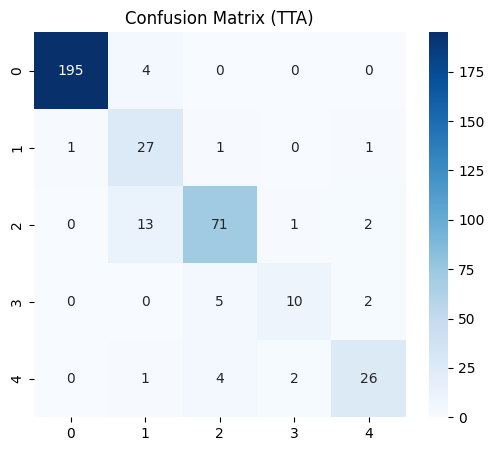

Saved predictions -> results/full_model_cv0_seed0_preds.json

>>> CV fold 1/5 | config=full_model | seed=0
Epoch 0  train_acc=0.5612  val_acc=0.7071  val_kappa=0.8179
Epoch 1  train_acc=0.6542  val_acc=0.7223  val_kappa=0.8495
Epoch 2  train_acc=0.7069  val_acc=0.7451  val_kappa=0.8845
Epoch 3  train_acc=0.7433  val_acc=0.8225  val_kappa=0.8954
Epoch 4  train_acc=0.7653  val_acc=0.8270  val_kappa=0.9012
Epoch 5  train_acc=0.7884  val_acc=0.8164  val_kappa=0.8988


100%|██████████| 366/366 [01:15<00:00,  4.86it/s]


Epoch 0  train_acc=0.6803  val_acc=0.8240  val_kappa=0.9009
Epoch 1  train_acc=0.8149  val_acc=0.8467  val_kappa=0.9007
Epoch 2  train_acc=0.8426  val_acc=0.8483  val_kappa=0.8963
Epoch 3  train_acc=0.8608  val_acc=0.8528  val_kappa=0.8996
Epoch 4  train_acc=0.8654  val_acc=0.8756  val_kappa=0.9177

Final Accuracy (TTA): 0.8989071038251366
Quadratic Weighted Kappa (TTA): 0.9300556751729497

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       199
           1       0.63      0.90      0.74        30
           2       0.92      0.83      0.87        87
           3       0.64      0.53      0.58        17
           4       0.76      0.79      0.78        33

    accuracy                           0.90       366
   macro avg       0.79      0.80      0.79       366
weighted avg       0.91      0.90      0.90       366



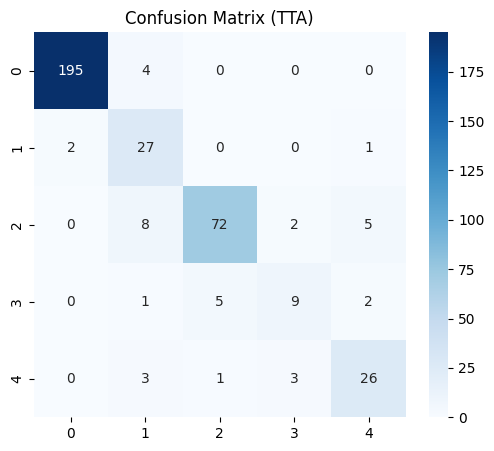

Saved predictions -> results/full_model_cv1_seed0_preds.json

>>> CV fold 2/5 | config=full_model | seed=0
Epoch 0  train_acc=0.5381  val_acc=0.6677  val_kappa=0.7849
Epoch 1  train_acc=0.6724  val_acc=0.7071  val_kappa=0.8881
Epoch 2  train_acc=0.7137  val_acc=0.8027  val_kappa=0.8938
Epoch 3  train_acc=0.7600  val_acc=0.7390  val_kappa=0.8673
Epoch 4  train_acc=0.7747  val_acc=0.8088  val_kappa=0.8969
Epoch 5  train_acc=0.7933  val_acc=0.7906  val_kappa=0.8955


100%|██████████| 366/366 [00:53<00:00,  6.83it/s]


Epoch 0  train_acc=0.6860  val_acc=0.8392  val_kappa=0.9201
Epoch 1  train_acc=0.8146  val_acc=0.8756  val_kappa=0.9300
Epoch 2  train_acc=0.8115  val_acc=0.8801  val_kappa=0.9252
Epoch 3  train_acc=0.8422  val_acc=0.8938  val_kappa=0.9324
Epoch 4  train_acc=0.8673  val_acc=0.8968  val_kappa=0.9333

Final Accuracy (TTA): 0.8989071038251366
Quadratic Weighted Kappa (TTA): 0.9473019147701631

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       199
           1       0.77      0.90      0.83        30
           2       0.90      0.84      0.87        87
           3       0.52      0.76      0.62        17
           4       0.78      0.64      0.70        33

    accuracy                           0.90       366
   macro avg       0.79      0.82      0.80       366
weighted avg       0.91      0.90      0.90       366



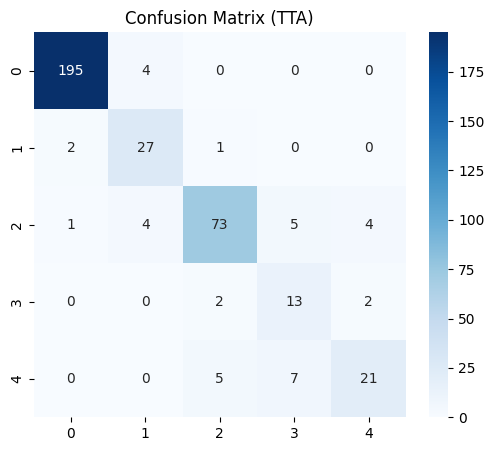

Saved predictions -> results/full_model_cv2_seed0_preds.json

>>> CV fold 3/5 | config=full_model | seed=0
Epoch 0  train_acc=0.5829  val_acc=0.7405  val_kappa=0.8822
Epoch 1  train_acc=0.6792  val_acc=0.6829  val_kappa=0.8083
Epoch 2  train_acc=0.7205  val_acc=0.7693  val_kappa=0.8912
Epoch 3  train_acc=0.7550  val_acc=0.7997  val_kappa=0.8836
Epoch 4  train_acc=0.7782  val_acc=0.7830  val_kappa=0.9036
Epoch 5  train_acc=0.7842  val_acc=0.7936  val_kappa=0.9036


100%|██████████| 366/366 [00:52<00:00,  6.98it/s]


Epoch 0  train_acc=0.6739  val_acc=0.8285  val_kappa=0.9126
Epoch 1  train_acc=0.7899  val_acc=0.8801  val_kappa=0.9268
Epoch 2  train_acc=0.8392  val_acc=0.8968  val_kappa=0.9367
Epoch 3  train_acc=0.8483  val_acc=0.8847  val_kappa=0.9268
Epoch 4  train_acc=0.8642  val_acc=0.9014  val_kappa=0.9331

Final Accuracy (TTA): 0.8715846994535519
Quadratic Weighted Kappa (TTA): 0.9350617849586977

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       199
           1       0.68      0.70      0.69        30
           2       0.83      0.86      0.85        87
           3       0.41      0.71      0.52        17
           4       0.89      0.48      0.63        33

    accuracy                           0.87       366
   macro avg       0.76      0.75      0.73       366
weighted avg       0.89      0.87      0.87       366



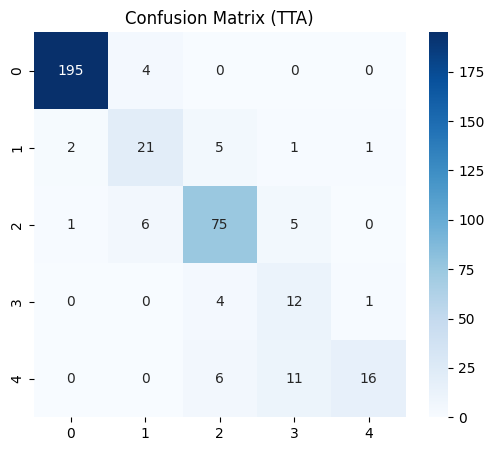

Saved predictions -> results/full_model_cv3_seed0_preds.json

>>> CV fold 4/5 | config=full_model | seed=0
Epoch 0  train_acc=0.5586  val_acc=0.7253  val_kappa=0.8290
Epoch 1  train_acc=0.6386  val_acc=0.7451  val_kappa=0.8581
Epoch 2  train_acc=0.6894  val_acc=0.8376  val_kappa=0.9184
Epoch 3  train_acc=0.7364  val_acc=0.8134  val_kappa=0.9115
Epoch 4  train_acc=0.7827  val_acc=0.8361  val_kappa=0.8964
Epoch 5  train_acc=0.7911  val_acc=0.8103  val_kappa=0.8993


100%|██████████| 366/366 [00:57<00:00,  6.40it/s]


Epoch 0  train_acc=0.6674  val_acc=0.8998  val_kappa=0.9427
Epoch 1  train_acc=0.8020  val_acc=0.8998  val_kappa=0.9532
Epoch 2  train_acc=0.8320  val_acc=0.9059  val_kappa=0.9550
Epoch 3  train_acc=0.8487  val_acc=0.9029  val_kappa=0.9470
Epoch 4  train_acc=0.8536  val_acc=0.9211  val_kappa=0.9532

Final Accuracy (TTA): 0.8989071038251366
Quadratic Weighted Kappa (TTA): 0.9492194003662863

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       199
           1       0.76      0.87      0.81        30
           2       0.92      0.87      0.89        87
           3       0.43      0.71      0.53        17
           4       0.81      0.67      0.73        33

    accuracy                           0.90       366
   macro avg       0.78      0.82      0.79       366
weighted avg       0.91      0.90      0.90       366



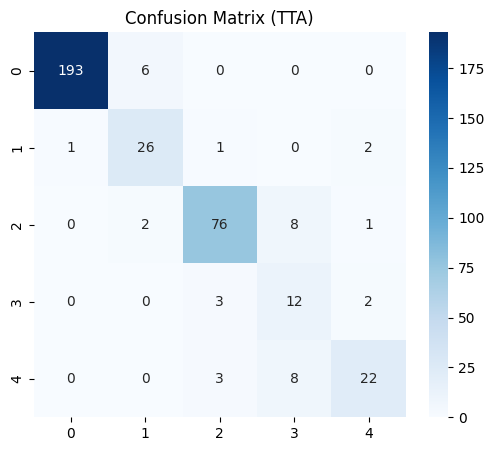

Saved predictions -> results/full_model_cv4_seed0_preds.json


,run_name,config,seed,acc,kappa,base_config,fold
0,full_model_cv0_seed0,full_model_cv0,0,0.898907,0.943585,full_model,0
1,full_model_cv1_seed0,full_model_cv1,0,0.898907,0.930056,full_model,1
2,full_model_cv2_seed0,full_model_cv2,0,0.898907,0.947302,full_model,2
3,full_model_cv3_seed0,full_model_cv3,0,0.871585,0.935062,full_model,3
4,full_model_cv4_seed0,full_model_cv4,0,0.898907,0.949219,full_model,4


In [25]:
# =========================================================
# STRATIFIED K-FOLD CROSS-VALIDATION
# =========================================================
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
CV_SEEDS = [0]                 # add more seeds per fold if you also want seed-variance within CV
CV_CONFIGS = ["full_model"]    # e.g. ["full_model", "no_augmentation"] to CV-check an ablation too


def run_cross_validation(config_name, cfg, n_folds, seeds, train_df, val_df, test_df,
                          train_dir, val_dir, test_dir, epoch_budget=ABLATION_EPOCH_BUDGET,
                          csv_path="results/cv_results.csv"):
    # Resolve to absolute paths up front so train/val images (which live in
    # different directories) can be pooled into one dataframe safely --
    # EyeDataset just does os.path.join(image_dir, id_code), and
    # os.path.join("", "/abs/path.png") returns the absolute path unchanged,
    # so passing image_dir="" downstream works once id_code holds full paths.
    train_abs = train_df.copy()
    train_abs["id_code"] = train_abs["id_code"].apply(lambda f: os.path.abspath(os.path.join(train_dir, f)))
    val_abs = val_df.copy()
    val_abs["id_code"] = val_abs["id_code"].apply(lambda f: os.path.abspath(os.path.join(val_dir, f)))
    cv_pool = pd.concat([train_abs, val_abs], ignore_index=True)

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seeds[0])

    rows = []
    if os.path.exists(csv_path):
        rows = pd.read_csv(csv_path).to_dict("records")  # resume support

    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(cv_pool, cv_pool["diagnosis"])):
        fold_train_df = cv_pool.iloc[tr_idx].reset_index(drop=True)
        fold_val_df = cv_pool.iloc[va_idx].reset_index(drop=True)

        for seed in seeds:
            run_id = f"{config_name}_cv{fold_idx}"
            already_done = any(r["run_name"] == f"{run_id}_seed{seed}" for r in rows)
            if already_done:
                print(f"Skipping {run_id}_seed{seed} (already in {csv_path})")
                continue

            print(f"\n>>> CV fold {fold_idx}/{n_folds} | config={config_name} | seed={seed}")
            result = run_ablation_config(run_id, cfg, seed, fold_train_df, fold_val_df, test_df,
                                          train_dir="", val_dir="", test_dir=test_dir,
                                          epoch_budget=epoch_budget)

            row = {k: v for k, v in result.items() if k not in ("y_true", "y_pred")}
            row["base_config"] = config_name
            row["fold"] = fold_idx
            rows.append(row)

            pd.DataFrame(rows).to_csv(csv_path, index=False)  # incremental save after every run

    return pd.DataFrame(rows)


cv_rows = []
for config_name in CV_CONFIGS:
    cfg = ABLATION_CONFIGS[config_name]
    cv_result_df = run_cross_validation(config_name, cfg, N_FOLDS, CV_SEEDS,
                                         train_df, val_df, test_df, train_dir, val_dir, test_dir)
    cv_rows.append(cv_result_df)

cv_results_df = pd.concat(cv_rows, ignore_index=True) if cv_rows else pd.DataFrame()
cv_results_df


In [26]:
# =========================================================
# CV SUMMARY (mean +/- std across folds) -> CSV
# =========================================================
def summarize_cv(cv_results_df, csv_path="results/cv_summary.csv"):
    summary = (
        cv_results_df
        .groupby("base_config")[["acc", "kappa"]]
        .agg(["mean", "std", "min", "max", "count"])
    )
    summary.columns = ["_".join(c) for c in summary.columns]
    summary = summary.reset_index()
    summary.to_csv(csv_path, index=False)
    print(f"Saved CV summary -> {csv_path}")
    return summary


if len(cv_results_df):
    cv_summary_df = summarize_cv(cv_results_df)
    cv_summary_df


Saved CV summary -> results/cv_summary.csv


## Was the original single-split result representative?

Your originally reported number (Stage 6, single train/valid/test split) was
**acc = 0.9044, kappa = 0.9518**. That came from one particular way of splitting the data --
5-fold CV tells you whether that split happened to be a lucky one, an unlucky one, or a
typical one, by showing where it falls relative to the spread across 5 different splits.

In [27]:
# =========================================================
# ORIGINAL SINGLE-SPLIT RESULT vs 5-FOLD CV SPREAD
# =========================================================
ORIGINAL_RUN = dict(acc=0.9043715846994536, kappa=0.9518186808037806)

def compare_original_to_cv(cv_results_df, original_run=ORIGINAL_RUN, config_name="full_model"):
    fold_rows = cv_results_df[cv_results_df["base_config"] == config_name]
    if len(fold_rows) == 0:
        print(f"No CV rows found for config={config_name} -- run the CV sweep first.")
        return None

    for metric in ["acc", "kappa"]:
        vals = fold_rows[metric].values
        mean, std = vals.mean(), vals.std(ddof=1)
        lo, hi = mean - 1.96 * std / np.sqrt(len(vals)), mean + 1.96 * std / np.sqrt(len(vals))
        orig = original_run[metric]

        z = (orig - mean) / std if std > 0 else float("nan")
        within_1sd = abs(orig - mean) <= std

        print(f"\n{metric.upper()}")
        print(f"  5-fold CV:      mean={mean:.4f}  std={std:.4f}  range=[{vals.min():.4f}, {vals.max():.4f}]")
        print(f"  95% CI of mean: ({lo:.4f}, {hi:.4f})")
        print(f"  Original run:   {orig:.4f}  ({z:+.2f} SD from CV mean, {'within' if within_1sd else 'OUTSIDE'} 1 SD)")

    comparison_df = pd.DataFrame({
        "fold": list(fold_rows["fold"]) + ["original_split"],
        "acc": list(fold_rows["acc"]) + [original_run["acc"]],
        "kappa": list(fold_rows["kappa"]) + [original_run["kappa"]],
    })
    comparison_df.to_csv("results/original_vs_cv_comparison.csv", index=False)
    return comparison_df


# Run once cv_results_df exists (i.e. after the CV sweep cell above has executed):
comparison_df = compare_original_to_cv(cv_results_df)



ACC
  5-fold CV:      mean=0.8934  std=0.0122  range=[0.8716, 0.8989]
  95% CI of mean: (0.8827, 0.9042)
  Original run:   0.9044  (+0.89 SD from CV mean, within 1 SD)

KAPPA
  5-fold CV:      mean=0.9410  std=0.0082  range=[0.9301, 0.9492]
  95% CI of mean: (0.9339, 0.9482)
  Original run:   0.9518  (+1.31 SD from CV mean, OUTSIDE 1 SD)


In [ ]:
master_df = build_master_results_csv()
manifest_df = build_predictions_manifest()

## Export everything to Excel

Pulls every results CSV produced above into one `.xlsx` workbook, one sheet per source, so you
have a single file to attach to a report instead of six separate CSVs. Each CSV is also still
saved on its own (unchanged) -- this just adds a consolidated copy on top.

In [28]:
!pip install openpyxl -q


In [29]:
# =========================================================
# EXPORT ALL RESULTS TO ONE EXCEL WORKBOOK
# =========================================================
def export_all_results_to_excel(xlsx_path="results/all_results.xlsx"):
    csv_files = {
        "ablation_results":   "results/ablation_results.csv",
        "cv_results":         "results/cv_results.csv",
        "cv_summary":         "results/cv_summary.csv",
        "original_vs_cv":     "results/original_vs_cv_comparison.csv",
        "all_results":        "results/all_results.csv",
        "predictions_manifest": "results/predictions_manifest.csv",
    }

    sheets = {}
    for sheet_name, path in csv_files.items():
        if os.path.exists(path):
            sheets[sheet_name] = pd.read_csv(path)
        else:
            print(f"Skipping '{sheet_name}': {path} not found yet")

    if not sheets:
        print("Nothing to export yet -- run the ablation/CV cells above first.")
        return None

    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        for sheet_name, df in sheets.items():
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)  # Excel caps sheet names at 31 chars

    print(f"Saved {len(sheets)} sheet(s) -> {xlsx_path}")
    return sheets


exported_sheets = export_all_results_to_excel()


Skipping 'all_results': results/all_results.csv not found yet
Skipping 'predictions_manifest': results/predictions_manifest.csv not found yet
Saved 4 sheet(s) -> results/all_results.xlsx
